# 02 — Pricing numérique : Monte Carlo vs Black-Scholes

**Objectif.** Comparer pricing analytique et numérique, et quantifier l'erreur Monte Carlo (convergence, erreur standard, intervalle de confiance, coût de calcul).

Sous la probabilité risque-neutre, $dS_t = (r-q)S_t\,dt + \sigma S_t\,dW_t$, d'où la simulation exacte (pas de biais de discrétisation pour un payoff européen) :

$$S_T = S_0 \exp\Big[\big(r - q - \tfrac12\sigma^2\big)T + \sigma\sqrt{T}\,Z\Big],\quad Z\sim\mathcal N(0,1), \qquad \hat C_N = e^{-rT}\frac1N\sum_{i=1}^N (S_T^{(i)} - K)^+$$

L'estimateur est sans biais, d'erreur standard $\hat\sigma_{payoff}/\sqrt N$ : l'erreur décroît en $N^{-1/2}$ (diviser l'erreur par 10 coûte 100× plus de simulations).

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting import set_style, savefig, save_table, PALETTE

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)
%matplotlib inline
import time
from black_scholes import black_scholes_price
from monte_carlo import price_monte_carlo, simulate_terminal_prices

## 1. Tableau de convergence

In [2]:
S, K, T, r, sigma = 100, 100.0, 1.0, 0.05, 0.20
bs_ref = black_scholes_price(S, K, T, r, sigma, "call")
rows = []
for n in [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]:
    t0 = time.perf_counter()
    res = price_monte_carlo(S, K, T, r, sigma, n, "call", seed=42)
    dt = time.perf_counter() - t0
    rows.append({"N simulations": n, "Prix MC": res["mc_price"], "Erreur std": res["se"],
                 "IC 95% bas": res["ci_95"][0], "IC 95% haut": res["ci_95"][1],
                 "Erreur abs. vs BS": res["abs_error"], "Erreur (%)": 100 * res["abs_error"] / bs_ref,
                 "BS dans l'IC": res["in_ci"], "Temps (ms)": 1000 * dt})
conv = pd.DataFrame(rows)
save_table(conv, "02_monte_carlo_convergence")
print(f"Prix Black-Scholes de référence : {bs_ref:.4f}")
conv

Prix Black-Scholes de référence : 10.4506


,N simulations,Prix MC,Erreur std,IC 95% bas,IC 95% haut,Erreur abs. vs BS,Erreur (%),BS dans l'IC,Temps (ms)
0,1000,10.5166,0.4730,9.5896,11.4436,0.0660,0.6314,True,0.4375
1,5000,10.4850,0.2076,10.0782,10.8918,0.0344,0.3295,True,0.4435
2,10000,10.4502,0.1478,10.1605,10.7399,0.0004,0.0040,True,0.5233
3,50000,10.4462,0.0657,10.3174,10.5749,0.0044,0.0423,True,2.5837
4,100000,10.4739,0.0466,10.3826,10.5652,0.0233,0.2230,True,3.8918
5,500000,10.4413,0.0208,10.4006,10.4821,0.0093,0.0886,True,24.0728
6,1000000,10.4342,0.0147,10.4053,10.4630,0.0164,0.1572,True,41.4775


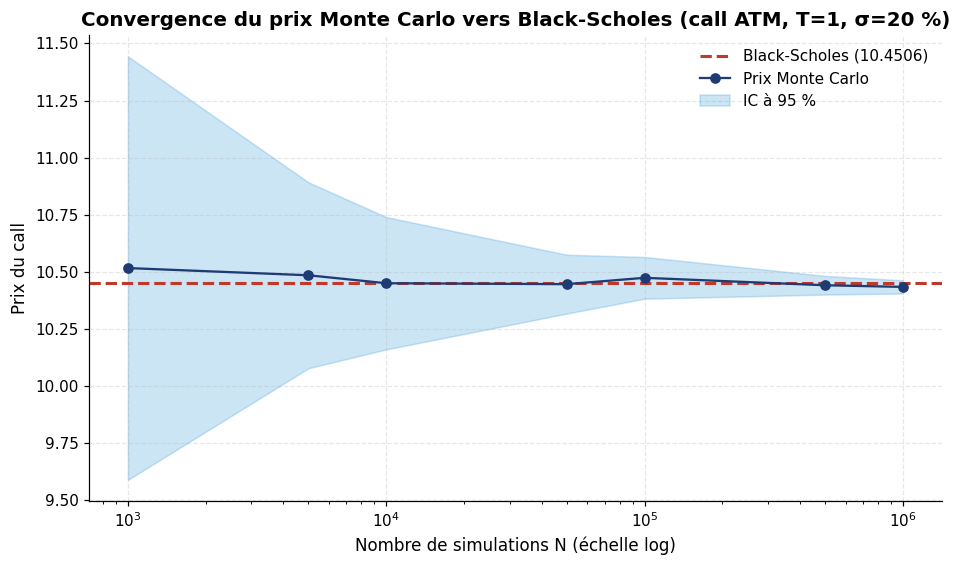

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axhline(bs_ref, color=PALETTE["crimson"], ls="--", lw=2, label=f"Black-Scholes ({bs_ref:.4f})")
ax.plot(conv["N simulations"], conv["Prix MC"], "o-", color=PALETTE["navy"], zorder=3, label="Prix Monte Carlo")
ax.fill_between(conv["N simulations"], conv["IC 95% bas"], conv["IC 95% haut"], color=PALETTE["sky"], alpha=0.25, label="IC à 95 %")
ax.set_xscale("log"); ax.set_xlabel("Nombre de simulations N (échelle log)"); ax.set_ylabel("Prix du call")
ax.set_title("Convergence du prix Monte Carlo vers Black-Scholes (call ATM, T=1, σ=20 %)"); ax.legend()
savefig(fig, "02_mc_convergence.png"); plt.show()

## 2. Vitesse de convergence : l'erreur décroît bien en $1/\sqrt{N}$

Une seule graine donne une trajectoire d'erreur bruitée. On mesure donc la **RMSE sur 200 graines** pour chaque $N$, et on la compare à la pente théorique $-1/2$ en log-log.

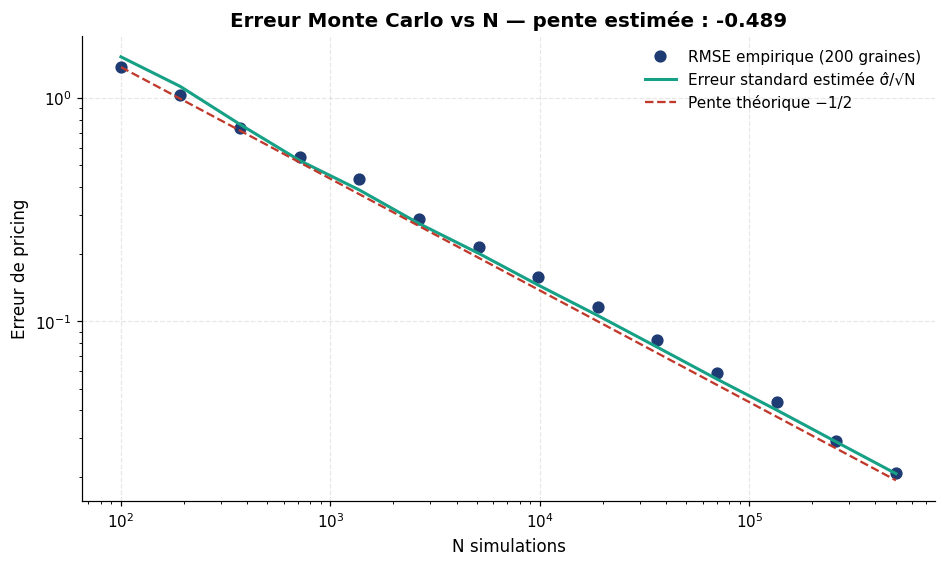

Pente log-log estimée : -0.489 (théorie : −0.5)


In [4]:
Ns = np.unique(np.logspace(2, 5.7, 14).astype(int))
rmse, se_mean = [], []
for n in Ns:
    errs = [price_monte_carlo(S, K, T, r, sigma, n, "call", seed=s)["mc_price"] - bs_ref for s in range(200)]
    rmse.append(np.sqrt(np.mean(np.square(errs))))
    se_mean.append(price_monte_carlo(S, K, T, r, sigma, n, "call", seed=0)["se"])
rmse = np.array(rmse)
slope = np.polyfit(np.log(Ns), np.log(rmse), 1)[0]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.loglog(Ns, rmse, "o", color=PALETTE["navy"], ms=7, label="RMSE empirique (200 graines)")
ax.loglog(Ns, se_mean, "-", color=PALETTE["teal"], lw=2, label="Erreur standard estimée σ̂/√N")
ax.loglog(Ns, rmse[0] * np.sqrt(Ns[0] / Ns), "--", color=PALETTE["crimson"], label="Pente théorique −1/2")
ax.set_xlabel("N simulations"); ax.set_ylabel("Erreur de pricing")
ax.set_title(f"Erreur Monte Carlo vs N — pente estimée : {slope:.3f}"); ax.legend()
savefig(fig, "02_mc_error_loglog.png"); plt.show()
print(f"Pente log-log estimée : {slope:.3f} (théorie : −0.5)")

## 3. Distribution simulée de $S_T$ vs densité log-normale théorique

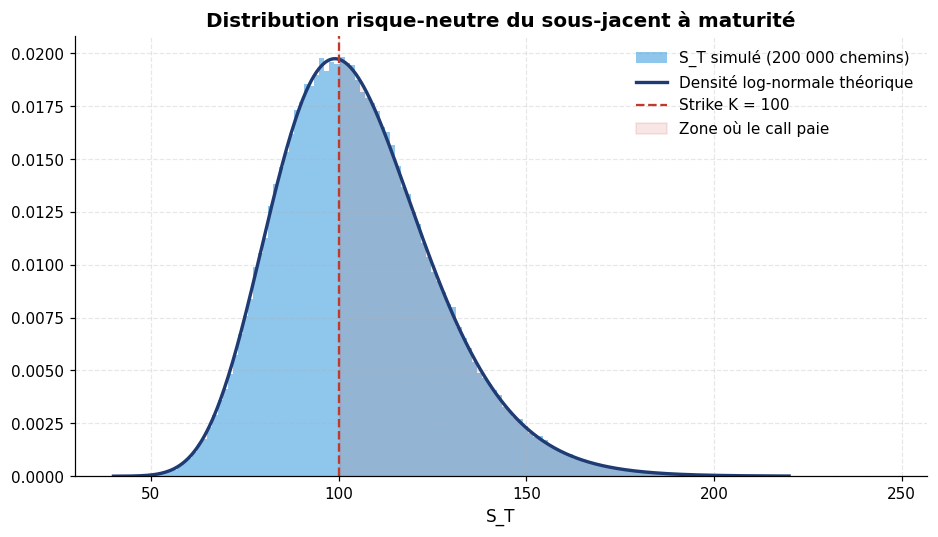

E[S_T] simulé = 105.212 | forward théorique S·e^(rT) = 105.127


In [5]:
from scipy.stats import lognorm
ST = simulate_terminal_prices(S, T, r, sigma, 200_000, seed=1)
mu = np.log(S) + (r - 0.5 * sigma**2) * T
x = np.linspace(40, 220, 500)
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.hist(ST, bins=150, density=True, color=PALETTE["sky"], alpha=0.55, label="S_T simulé (200 000 chemins)")
ax.plot(x, lognorm.pdf(x, s=sigma * np.sqrt(T), scale=np.exp(mu)), color=PALETTE["navy"], lw=2.2, label="Densité log-normale théorique")
ax.axvline(K, color=PALETTE["crimson"], ls="--", label="Strike K = 100")
ax.fill_between(x, 0, lognorm.pdf(x, s=sigma * np.sqrt(T), scale=np.exp(mu)), where=x > K, color=PALETTE["crimson"], alpha=0.12, label="Zone où le call paie")
ax.set_title("Distribution risque-neutre du sous-jacent à maturité"); ax.set_xlabel("S_T"); ax.legend()
savefig(fig, "02_mc_terminal_distribution.png"); plt.show()
print(f"E[S_T] simulé = {ST.mean():.3f} | forward théorique S·e^(rT) = {S*np.exp(r*T):.3f}")

## 4. Comparaison sur plusieurs contrats (100 000 chemins)

In [6]:
rows = []
for typ in ["call", "put"]:
    for K_ in [80, 100, 120]:
        res = price_monte_carlo(S, K_, T, r, sigma, 100_000, typ, q=0.01, seed=7)
        rows.append({"Type": typ, "Strike": K_, "Black-Scholes": res["bs_price"], "Monte Carlo": res["mc_price"],
                     "Écart (%)": 100 * (res["mc_price"] - res["bs_price"]) / res["bs_price"],
                     "Erreur std": res["se"], "|écart| / σ̂": res["abs_error"] / res["se"], "BS ∈ IC95": res["in_ci"]})
comp = pd.DataFrame(rows); save_table(comp, "02_bs_vs_mc_table"); comp

,Type,Strike,Black-Scholes,Monte Carlo,Écart (%),Erreur std,|écart| / σ̂,BS ∈ IC95
0,call,80,23.6683,23.5877,-0.3406,0.0593,1.3606,True
1,call,100,9.8263,9.7400,-0.8779,0.0447,1.9286,True
2,call,120,2.9701,2.9126,-1.9374,0.0257,2.2405,False
3,put,80,0.7617,0.7584,-0.4267,0.0089,0.3643,True
4,put,100,5.9443,5.9354,-0.1497,0.0281,0.3164,True
5,put,120,18.1126,18.1325,0.1095,0.0472,0.4196,True


## Conclusion

- Le Monte Carlo converge vers le prix analytique, avec une **pente log-log de −0.5** conforme à la théorie : l'erreur standard estimée $\hat\sigma/\sqrt N$ est un excellent prédicteur de l'erreur réelle.
- Le prix Black-Scholes tombe dans l'IC à 95 % pour 5 contrats sur 6 ; le call K=120 sort de peu (2.2 σ̂). Ce n'est pas une anomalie : les six prix utilisent la **même graine**, donc les mêmes $Z$ — les erreurs des trois calls sont corrélées (toutes négatives). Avec un IC à 95 %, on s'attend de toute façon à ~1 échec sur 20.
- À 1 000 000 de chemins, l'erreur est de l'ordre du centime pour une option à ~10 $ : le Monte Carlo est **inutile** quand une formule fermée existe, mais indispensable pour les modèles sans formule simple ou les payoffs path-dependent. C'est pourquoi on le réutilise pour simuler Heston (notebook 05) et les trajectoires de couverture (notebook 06).
- Pistes d'amélioration classiques : variables antithétiques, variable de contrôle (le forward ou le prix BS), quasi-Monte Carlo (Sobol).